In [11]:
%pip install pandas matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 10.8 MB 5.6 MB/s eta 0:00:01
     |████████████████████████████████| 7.8 MB 8.6 MB/s eta 0:00:01
     |████████████████████████████████| 294 kB 5.5 MB/s eta 0:00:01
     |████████████████████████████████| 11.1 MB 6.5 MB/s eta 0:00:01
     |████████████████████████████████| 349 kB 7.7 MB/s eta 0:00:01
     |████████████████████████████████| 510 kB 8.4 MB/s eta 0:00:01
     |████████████████████████████████| 64 kB 6.6 MB/s  eta 0:00:01
     |████████████████████████████████| 122 kB 9.4 MB/s eta 0:00:01
     |████████████████████████████████| 249 kB 10.5 MB/s eta 0:00:01
     |████████████████████████████████| 4.7 MB 9.5 MB/s eta 0:00:01
     |████████████████████████████████| 2.9 MB 10.6 MB/s eta 0:00:01
     |████████████████████████████████| 309 kB 9.0 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip inst

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,f1_score,roc_auc_score


In [14]:
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier

In [14]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [15]:
from sklearn.tree import DecisionTreeClassifier

In [17]:
%pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]1/2 [openpyxl]
Note: you may need to restart the kernel to use updated packages.


In [18]:
df = pd.read_excel('american_bankruptcy.xlsx')
df.head(20)

,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
0,C_1,alive,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,C_1,alive,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,C_1,alive,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,C_1,alive,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,C_1,alive,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467
5,C_1,alive,2004,474.542,598.172,27.950,61.774,255.477,15.453,127.121,...,747.848,732.230,227.159,33.824,149.676,160.025,142.450,747.848,417.486,686.074
6,C_1,alive,2005,624.454,704.081,29.222,91.877,323.592,35.163,136.272,...,897.284,978.819,318.576,62.655,193.203,187.788,183.550,897.284,556.102,805.407
7,C_1,alive,2006,645.721,837.171,32.199,118.907,342.593,58.660,181.691,...,1061.169,1067.633,253.611,86.708,223.998,256.506,242.153,1061.169,573.390,942.262
8,C_1,alive,2007,783.431,1080.895,39.952,168.522,435.608,75.144,202.472,...,1384.919,1362.010,507.918,128.570,304.024,218.499,318.184,1384.919,776.755,1216.397
9,C_1,alive,2008,851.312,1110.677,40.551,166.080,477.424,78.651,227.300,...,1423.976,1377.511,392.984,125.529,313.299,254.418,385.851,1423.976,720.616,1257.896


In [19]:
all_years = set(range(1999, 2019))  # all 20 years

# Find missing years per company
missing = df.groupby('company_name')['year'].apply(
    lambda x: sorted(all_years - set(x))
)

In [20]:
# Build summary table of incomplete companies
incomplete = missing[missing.apply(len) > 0].reset_index()
incomplete.columns = ['company_name', 'missing_years']
incomplete['missing_year_count'] = incomplete['missing_years'].apply(len)
incomplete = incomplete.sort_values('missing_year_count', ascending=False)

print('Total incomplete companies:', len(incomplete))
print(incomplete[['company_name', 'missing_year_count', 'missing_years']])

Total incomplete companies: 7799
     company_name  missing_year_count  \
4718        C_613                  19   
3188         C_45                  19   
3159       C_4471                  19   
4567       C_5973                  19   
3967       C_5334                  19   
...           ...                 ...   
2216       C_3466                   1   
2240       C_3491                   1   
5441       C_6853                   1   
2267        C_352                   1   
0             C_1                   1   

                                          missing_years  
4718  [2000, 2001, 2002, 2003, 2004, 2005, 2006, 200...  
3188  [2000, 2001, 2002, 2003, 2004, 2005, 2006, 200...  
3159  [2000, 2001, 2002, 2003, 2004, 2005, 2006, 200...  
4567  [1999, 2000, 2001, 2002, 2003, 2004, 2005, 200...  
3967  [2000, 2001, 2002, 2003, 2004, 2005, 2006, 200...  
...                                                 ...  
2216                                             [2014]  
2240      

In [21]:
#  Get companies with only 1 year of data
year_counts = df.groupby('company_name')['year'].count()
single_year_companies = year_counts[year_counts == 1].index

# Show with their year and status
result = df[df['company_name'].isin(single_year_companies)][['company_name', 'year', 'status_label']]
print('Total single-year companies:', len(result))
print(result.sort_values('company_name').to_string(index=False))

Total single-year companies: 755
company_name  year status_label
      C_1055  1999        alive
      C_1064  1999        alive
      C_1069  1999        alive
      C_1076  1999        alive
      C_1092  1999        alive
      C_1097  1999        alive
      C_1138  1999        alive
       C_115  1999        alive
      C_1152  1999        alive
      C_1155  1999        alive
      C_1158  1999        alive
      C_1159  1999        alive
      C_1161  1999        alive
      C_1183  1999        alive
       C_119  1999        alive
       C_121  1999        alive
      C_1218  1999        alive
      C_1221  1999        alive
      C_1223  1999        alive
      C_1235  2001        alive
      C_1256  2012        alive
      C_1259  1999        alive
      C_1264  1999        alive
      C_1281  1999        alive
      C_1287  1999        alive
      C_1290  1999        alive
      C_1303  1999        alive
      C_1322  2005        alive
      C_1323  1999        alive
      C

In [22]:
# Step 1 — Drop single year companies (safe, lose <1% of data)
year_counts = df.groupby('company_name')['year'].count()
single_year = year_counts[year_counts == 1].index
df = df[~df['company_name'].isin(single_year)]
print('After dropping single-year companies:', len(df), 'rows')

After dropping single-year companies: 77927 rows


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 77927 entries, 0 to 78681
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   company_name  77927 non-null  object 
 1   status_label  77927 non-null  object 
 2   year          77927 non-null  int64  
 3   X1            77927 non-null  float64
 4   X2            77927 non-null  float64
 5   X3            77927 non-null  float64
 6   X4            77927 non-null  float64
 7   X5            77927 non-null  float64
 8   X6            77927 non-null  float64
 9   X7            77927 non-null  float64
 10  X8            77927 non-null  float64
 11  X9            77927 non-null  float64
 12  X10           77927 non-null  float64
 13  X11           77927 non-null  float64
 14  X12           77927 non-null  float64
 15  X13           77927 non-null  float64
 16  X14           77927 non-null  float64
 17  X15           77927 non-null  float64
 18  X16           77927 non-null  f

In [23]:
df.describe

<bound method NDFrame.describe of       company_name status_label  year       X1       X2      X3       X4  \
0              C_1        alive  1999  511.267  833.107  18.373   89.031   
1              C_1        alive  2000  485.856  713.811  18.577   64.367   
2              C_1        alive  2001  436.656  526.477  22.496   27.207   
3              C_1        alive  2002  396.412  496.747  27.172   30.745   
4              C_1        alive  2003  432.204  523.302  26.680   47.491   
...            ...          ...   ...      ...      ...     ...      ...   
78677       C_8971        alive  2014  233.211   43.338  14.094   45.615   
78678       C_8971        alive  2015  105.559   59.184  42.592  202.133   
78679       C_8971        alive  2016   63.971   69.074  65.057   79.051   
78680       C_8971        alive  2017  135.207   66.527  65.330   69.171   
78681       C_8971        alive  2018   82.589   68.817  65.201   67.262   

            X5       X6       X7  ...        X9      

In [24]:
# Checking for null values
print(df.isnull().sum())

company_name    0
status_label    0
year            0
X1              0
X2              0
X3              0
X4              0
X5              0
X6              0
X7              0
X8              0
X9              0
X10             0
X11             0
X12             0
X13             0
X14             0
X15             0
X16             0
X17             0
X18             0
dtype: int64


In [23]:
# Sort — critical
df = df.sort_values(['company_name', 'year']).reset_index(drop=True)

# Target
df['target'] = (df['status_label'] == 'failed').astype(int)

features = [f'X{i}' for i in range(1, 19)]

# --- Option A: Forward fill within company ---
# For each company, fill the first row's missing lag
# with the company's own first available value
# This must happen BEFORE creating lag columns

# We do this by creating a helper — the first value
# per company for each feature, then using it to
# fill NaNs that arise after shifting

# --- 1. Lag 1 ---
for col in features:
    df[f'{col}_lag1'] = df.groupby('company_name')[col].shift(1)
    # Fill NaN at first row of each company with that company's own first value
    first_vals = df.groupby('company_name')[col].transform('first')
    df[f'{col}_lag1'] = df[f'{col}_lag1'].fillna(first_vals)

# --- 2. Lag 2 ---
for col in features:
    df[f'{col}_lag2'] = df.groupby('company_name')[col].shift(2)
    first_vals = df.groupby('company_name')[col].transform('first')
    df[f'{col}_lag2'] = df[f'{col}_lag2'].fillna(first_vals)

# --- 3. Year over year change ---
# With Option A lags filled, yoy is now computable for all rows
# First row yoy will be 0 (current minus itself = 0)
for col in features:
    df[f'{col}_yoy'] = df[col] - df[f'{col}_lag1']

# --- 4. 3 year rolling mean ---
# min_periods=1 means it uses whatever years are available
# so first year uses 1 year, second uses 2, third onwards uses 3
for col in features:
    df[f'{col}_roll3'] = df.groupby('company_name')[col].transform(
        lambda x: x.rolling(window=3, min_periods=1).mean()
    )

# --- Verify no NaNs remain ---
lag_cols = ([f'{col}_lag1' for col in features] +
            [f'{col}_lag2' for col in features] +
            [f'{col}_yoy'  for col in features] +
            [f'{col}_roll3' for col in features])

print('NaNs remaining after Option A fill:')
print(df[lag_cols].isnull().sum().sum())  # Should be 0
print()

NaNs remaining after Option A fill:
0



In [26]:
import sys
!{sys.executable} -m pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [27]:
import sys
!{sys.executable} -m pip uninstall xgboost -y
!{sys.executable} -m pip install xgboost==1.7.6

Found existing installation: xgboost 2.1.4
Uninstalling xgboost-2.1.4:
  Successfully uninstalled xgboost-2.1.4
Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 1.6 MB 8.6 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [28]:
import sys
!{sys.executable} -m pip uninstall xgboost -y
!{sys.executable} -m pip install xgboost==2.0.3

Found existing installation: xgboost 1.7.6
Uninstalling xgboost-1.7.6:
  Successfully uninstalled xgboost-1.7.6
Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 1.9 MB 7.6 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [24]:
import pandas as pd
print(pd.__version__)

2.3.3


In [25]:
import site
print(site.getsitepackages())
!pip show xgboost

['/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages']
Name: xgboost
Version: 3.2.0
Summary: XGBoost Python Package
Home-page: 
Author: 
Author-email: Hyunsu Cho <chohyu01@cs.washington.edu>, Jiaming Yuan <jm.yuan@outlook.com>
License: Apache-2.0
Location: /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages
Requires: numpy, scipy
Required-by: 


In [31]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [32]:
import sys
print(sys.executable)
print(sys.version)

/Library/Developer/CommandLineTools/usr/bin/python3
3.9.6 (default, Apr 30 2025, 02:07:17) 
[Clang 17.0.0 (clang-1700.0.13.5)]


In [26]:
import xgboost as xgb

In [27]:
from xgboost import XGBClassifier

In [28]:
# Defining features and target
FEATURES = (
    features +
    [f'{col}_lag1'  for col in features] +
    [f'{col}_lag2'  for col in features] +
    [f'{col}_yoy'   for col in features] +
    [f'{col}_roll3' for col in features] +
    ['year']
)

# Splits
train = df[df['year'].between(1999, 2011)]
val   = df[df['year'].between(2012, 2014)]
test  = df[df['year'].between(2015, 2018)]

X_train, y_train = train[FEATURES], train['target']
X_val,   y_val   = val[FEATURES],   val['target']
X_test,  y_test  = test[FEATURES],  test['target']


In [29]:
print('Data ready. Train:', X_train.shape)
print('Validation:', X_val.shape)
print('Test:', X_test.shape)

Data ready. Train: (55337, 91)
Validation: (10407, 91)
Test: (12183, 91)


In [30]:
import sys
!{sys.executable} -m pip install optuna

In [31]:
import optuna
from sklearn.metrics import roc_auc_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [32]:
import sklearn
print(sklearn.__version__)

1.9.0


In [44]:
import sys
print(sys.executable)  # first confirm which Python is active
!{sys.executable} -m pip install scikit-learn

/Library/Developer/CommandLineTools/usr/bin/python3
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [45]:
import sklearn
import xgboost as xgb
print(sklearn.__version__)
print(xgb.__version__)

1.6.1
2.1.4


In [1]:
import sys
print(sys.executable)
print(sys.version)

/usr/local/bin/python3
3.13.7 (v3.13.7:bcee1c32211, Aug 14 2025, 19:10:51) [Clang 16.0.0 (clang-1600.0.26.6)]


In [33]:
def objective(trial):
    params = {
        'n_estimators'        : trial.suggest_int('n_estimators', 100, 800),
        'max_depth'           : trial.suggest_int('max_depth', 3, 7),
        'learning_rate'       : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'           : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'    : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'           : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'          : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'min_child_weight'    : trial.suggest_int('min_child_weight', 1, 20),
        'scale_pos_weight'    : trial.suggest_float('scale_pos_weight', 8.0, 15.0),
        'random_state'        : 42,
        'eval_metric'         : 'auc',
        'verbosity'           : 0,
        'early_stopping_rounds': 20   # moved here in XGBoost 2.x
    }

    model = xgb.XGBClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set = [(X_val, y_val)],
        verbose  = False
    )

    preds = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, preds)

# Run 50 trials — increase to 100 if you have time
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print('Best AUC on validation:', round(study.best_value, 4))
print('Best hyperparameters:')
for key, val in study.best_params.items():
    print(f'  {key}: {val}')



Best trial: 31. Best value: 0.88023: 100%|██████████| 50/50 [04:12<00:00,  5.05s/it] 

Best AUC on validation: 0.8802
Best hyperparameters:
  n_estimators: 607
  max_depth: 7
  learning_rate: 0.03378875888298855
  subsample: 0.8275005109493524
  colsample_bytree: 0.8077493286180382
  reg_alpha: 3.467818218646328
  reg_lambda: 3.795337861421397
  min_child_weight: 6
  scale_pos_weight: 8.862582238229184


In [34]:
# Training the model with best hyperparameters on combined train + val
best_params = study.best_params.copy()
best_params['random_state']         = 42
best_params['eval_metric']          = 'auc'
best_params['verbosity']            = 0
best_params['early_stopping_rounds'] = 20

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(
    X_train, y_train,
    eval_set = [(X_val, y_val)],
    verbose  = False
)

print('Final model trained.')
print('Best iteration:', final_model.best_iteration)

Final model trained.
Best iteration: 501


In [35]:
import numpy as np
from sklearn.metrics import f1_score

val_probs = final_model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores  = []

for thresh in thresholds:
    preds = (val_probs >= thresh).astype(int)
    f1_scores.append(f1_score(y_val, preds))

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1        = max(f1_scores)

print(f'Optimal threshold: {best_threshold:.2f}')
print(f'Best F1 at that threshold: {best_f1:.4f}')

Optimal threshold: 0.50
Best F1 at that threshold: 0.3811


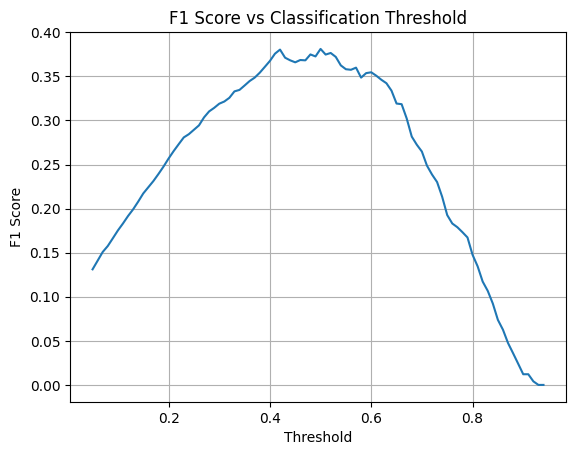

In [39]:
import matplotlib.pyplot as plt

plt.plot(thresholds, f1_scores)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Classification Threshold")
plt.grid(True)
plt.show()

In [40]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score)

val_preds = (val_probs >= best_threshold).astype(int)

print('=== VALIDATION SET RESULTS ===')
print(f'AUC-ROC:  {roc_auc_score(y_val, val_probs):.4f}')
print(f'F1 Score: {f1_score(y_val, val_preds):.4f}')
print(f'Threshold used: {best_threshold:.2f}')
print()
print('Classification Report:')
print(classification_report(y_val, val_preds,
      target_names=['Alive (0)', 'Failed (1)']))
print()
cm = confusion_matrix(y_val, val_preds)
print('Confusion Matrix:')
print(f'                   Predicted Alive  Predicted Failed')
print(f'Actual Alive       {cm[0][0]:<16}   {cm[0][1]}')
print(f'Actual Failed      {cm[1][0]:<16}   {cm[1][1]}')

=== VALIDATION SET RESULTS ===
AUC-ROC:  0.8802
F1 Score: 0.3811
Threshold used: 0.50

Classification Report:
              precision    recall  f1-score   support

   Alive (0)       0.97      0.97      0.97      9916
  Failed (1)       0.37      0.40      0.38       491

    accuracy                           0.94     10407
   macro avg       0.67      0.68      0.67     10407
weighted avg       0.94      0.94      0.94     10407


Confusion Matrix:
                   Predicted Alive  Predicted Failed
Actual Alive       9583               333
Actual Failed      297                194


In [37]:
test_probs = final_model.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= best_threshold).astype(int)

print('=== TEST SET RESULTS (final) ===')
print(f'AUC-ROC:  {roc_auc_score(y_test, test_probs):.4f}')
print(f'F1 Score: {f1_score(y_test, test_preds):.4f}')
print(f'Threshold used: {best_threshold:.2f}')
print()
print('Classification Report:')
print(classification_report(y_test, test_preds,
      target_names=['Alive (0)', 'Failed (1)']))
print()
cm = confusion_matrix(y_test, test_preds)
print('Confusion Matrix:')
print(f'                   Predicted Alive  Predicted Failed')
print(f'Actual Alive       {cm[0][0]:<16}   {cm[0][1]}')
print(f'Actual Failed      {cm[1][0]:<16}   {cm[1][1]}')

=== TEST SET RESULTS (final) ===
AUC-ROC:  0.8569
F1 Score: 0.2739
Threshold used: 0.50

Classification Report:
              precision    recall  f1-score   support

   Alive (0)       0.99      0.95      0.97     11898
  Failed (1)       0.19      0.50      0.27       285

    accuracy                           0.94     12183
   macro avg       0.59      0.72      0.62     12183
weighted avg       0.97      0.94      0.95     12183


Confusion Matrix:
                   Predicted Alive  Predicted Failed
Actual Alive       11282              616
Actual Failed      142                143


In [41]:
pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [shap]2/3 [shap]
Note: you may need to restart the kernel to use updated packages.


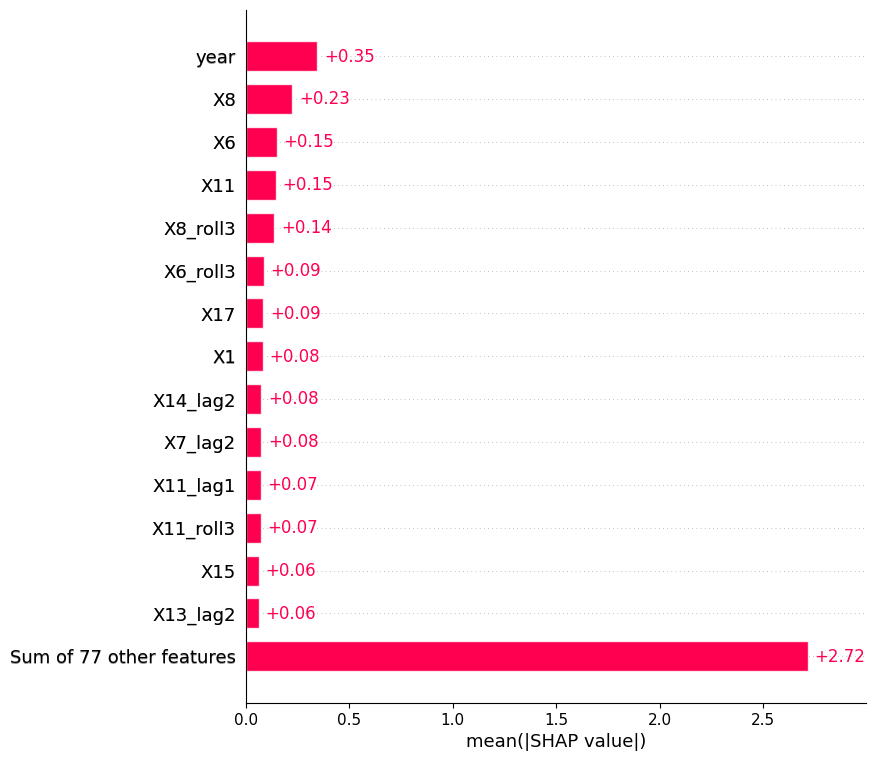

In [42]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(final_model)

shap_values = explainer(X_test)

shap.plots.bar(shap_values, max_display=15)

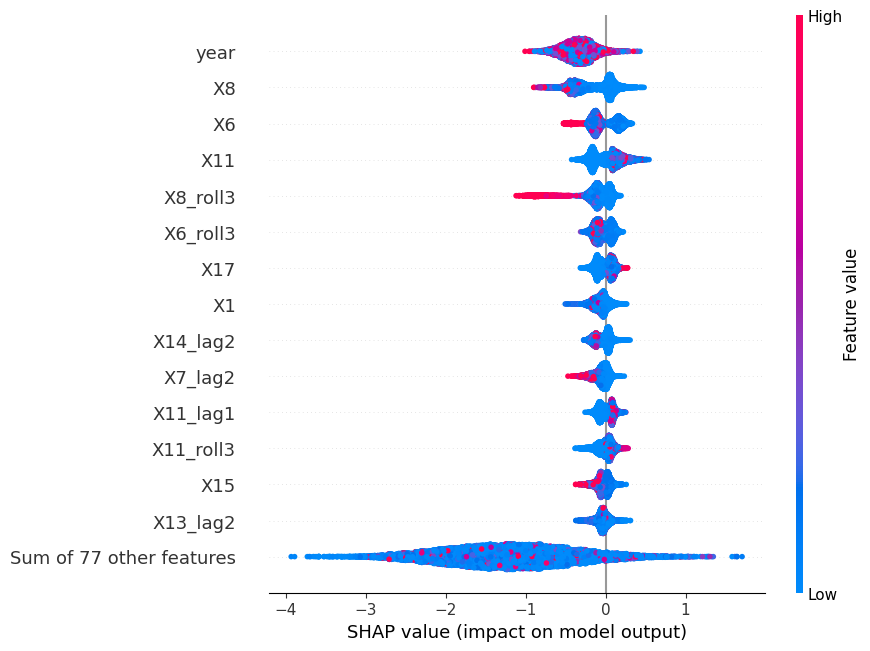

In [43]:
shap.plots.beeswarm(shap_values, max_display=15)

 98%|===================| 983/1000 [16:51<00:17]        

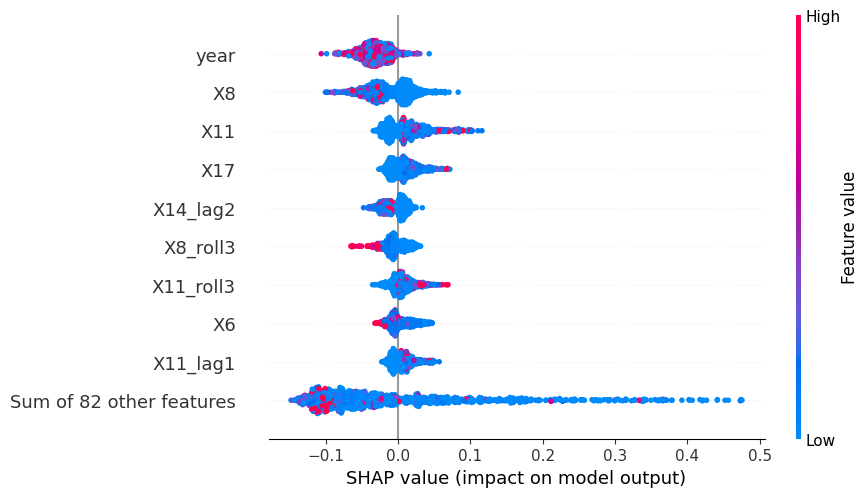

In [48]:
X_test_sample = X_test.sample(1000, random_state=42)

shap_values = explainer(X_test_sample)

shap.plots.beeswarm(shap_values)

In [49]:
import numpy as np
from sklearn.metrics import f1_score

val_probs = final_model.predict_proba(X_val)[:, 1]

# Check the actual probability distribution
print('Probability stats for FAILED companies:')
failed_mask = y_val == 1
print(f'  Mean:   {val_probs[failed_mask].mean():.3f}')
print(f'  Median: {np.median(val_probs[failed_mask]):.3f}')
print(f'  Min:    {val_probs[failed_mask].min():.3f}')
print(f'  Max:    {val_probs[failed_mask].max():.3f}')

print('Probability stats for ALIVE companies:')
alive_mask = y_val == 0
print(f'  Mean:   {val_probs[alive_mask].mean():.3f}')
print(f'  Median: {np.median(val_probs[alive_mask]):.3f}')

# Search thresholds more granularly at the low end
thresholds = np.arange(0.01, 0.50, 0.005)
results = []

for thresh in thresholds:
    preds = (val_probs >= thresh).astype(int)
    f1 = f1_score(y_val, preds, zero_division=0)
    precision = (preds[y_val==1].sum()) / (preds.sum() + 1e-9)
    recall = (preds[y_val==1].sum()) / (y_val.sum())
    results.append({
        'threshold': round(thresh, 3),
        'f1': round(f1, 4),
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'flagged': preds.sum()
    })

results_df = pd.DataFrame(results)
best_idx = results_df['f1'].idxmax()
best_threshold = results_df.loc[best_idx, 'threshold']

print()
print('Top 10 thresholds by F1:')
print(results_df.nlargest(10, 'f1').to_string(index=False))
print()
print(f'Optimal threshold: {best_threshold}')
print(f'At this threshold:')
print(results_df.loc[best_idx].to_string())

Probability stats for FAILED companies:
  Mean:   0.438
  Median: 0.426
  Min:    0.035
  Max:    0.927
Probability stats for ALIVE companies:
  Mean:   0.135
  Median: 0.083

Top 10 thresholds by F1:
 threshold     f1  precision  recall  flagged
     0.420 0.3804     0.3022  0.5132      834
     0.425 0.3779     0.3033  0.5010      811
     0.415 0.3778     0.2969  0.5193      859
     0.495 0.3761     0.3571  0.3971      546
     0.410 0.3757     0.2930  0.5234      877
     0.480 0.3749     0.3429  0.4134      592
     0.490 0.3726     0.3494  0.3992      561
     0.430 0.3712     0.3015  0.4827      786
     0.485 0.3708     0.3432  0.4033      577
     0.405 0.3704     0.2860  0.5255      902

Optimal threshold: 0.42
At this threshold:
threshold      0.4200
f1             0.3804
precision      0.3022
recall         0.5132
flagged      834.0000


In [50]:
FEATURE_NAMES = {
    'X1':  'Current Assets',
    'X2':  'Cost of Goods Sold',
    'X3':  'Depreciation & Amortization',
    'X4':  'EBITDA',
    'X5':  'Inventory',
    'X6':  'Net Income',
    'X7':  'Total Receivables',
    'X8':  'Market Value',
    'X9':  'Net Sales',
    'X10': 'Total Assets',
    'X11': 'Total Long-term Debt',
    'X12': 'EBIT',
    'X13': 'Gross Profit',
    'X14': 'Total Current Liabilities',
    'X15': 'Retained Earnings',
    'X16': 'Total Revenue',
    'X17': 'Total Liabilities',
    'X18': 'Total Operating Expenses',
}

def label(col):
    # Converts X8_roll3 -> Market Value (3Y Avg)
    # Converts X6_lag1  -> Net Income (1Y Lag)
    # Converts X4_yoy   -> EBITDA (YoY Change)
    for code, name in FEATURE_NAMES.items():
        if col.startswith(code) and (
            len(col) == len(code) or col[len(code)] == '_'
        ):
            suffix = col[len(code):]
            suffix_map = {
                '':       '',
                '_lag1':  ' (1Y Lag)',
                '_lag2':  ' (2Y Lag)',
                '_yoy':   ' (YoY Change)',
                '_roll3': ' (3Y Avg)',
            }
            return name + suffix_map.get(suffix, suffix)
    return col

# Build readable feature name list
FEATURE_LABELS = [label(f) for f in FEATURES]
print('Sample labels:')
for f, l in zip(FEATURES[:6], FEATURE_LABELS[:6]):
    print(f'  {f:20} -> {l}')

Sample labels:
  X1                   -> Current Assets
  X2                   -> Cost of Goods Sold
  X3                   -> Depreciation & Amortization
  X4                   -> EBITDA
  X5                   -> Inventory
  X6                   -> Net Income


In [51]:
import shap
import numpy as np

explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test[FEATURES])

print('SHAP values computed.')
print('Shape:', shap_values.shape)

SHAP values computed.
Shape: (12183, 91)


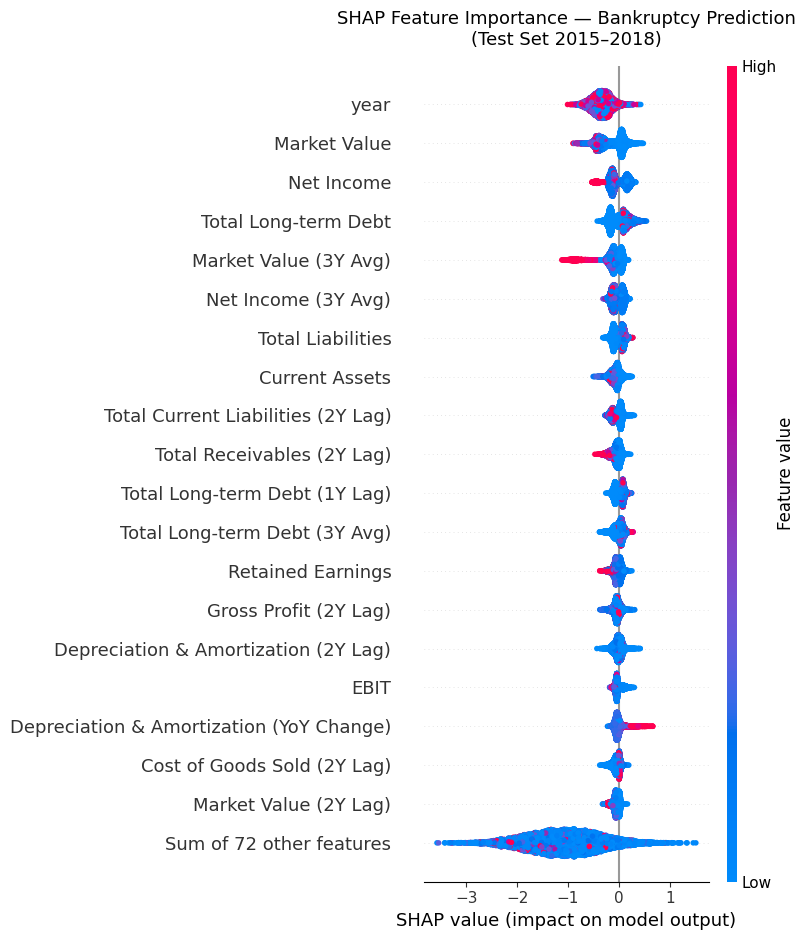

Saved: shap_global_beeswarm.png


In [52]:
import matplotlib.pyplot as plt

# Rename columns for readable plot
X_test_labeled = X_test[FEATURES].copy()
X_test_labeled.columns = FEATURE_LABELS

shap_df = shap.Explanation(
    values    = shap_values,
    base_values = explainer.expected_value,
    data      = X_test_labeled.values,
    feature_names = FEATURE_LABELS
)

plt.figure(figsize=(12, 10))
shap.plots.beeswarm(shap_df, max_display=20, show=False)
plt.title('SHAP Feature Importance — Bankruptcy Prediction\n(Test Set 2015–2018)',
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('shap_global_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_global_beeswarm.png')

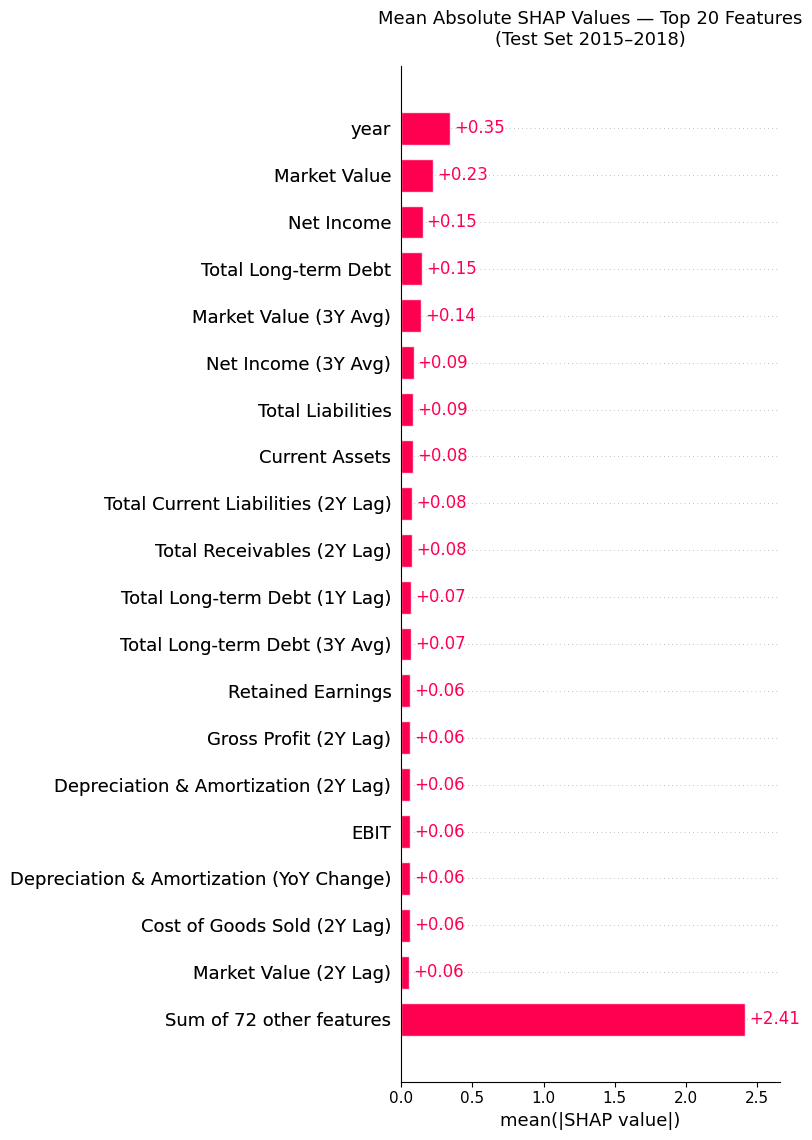

In [53]:
plt.figure(figsize=(12, 8))
shap.plots.bar(shap_df, max_display=20, show=False)
plt.title('Mean Absolute SHAP Values — Top 20 Features\n(Test Set 2015–2018)',
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('shap_global_bar.png', dpi=150, bbox_inches='tight')
plt.show()

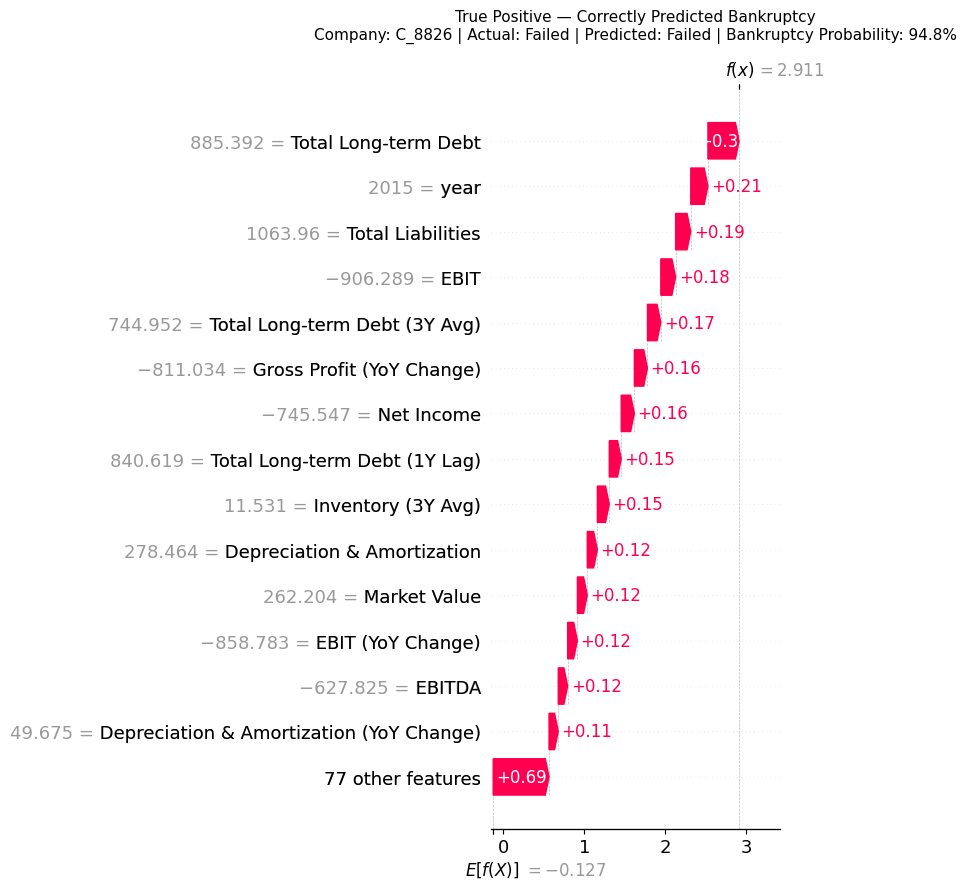

Saved: shap_true_positive_—_correctly_predicted_bankruptcy.png


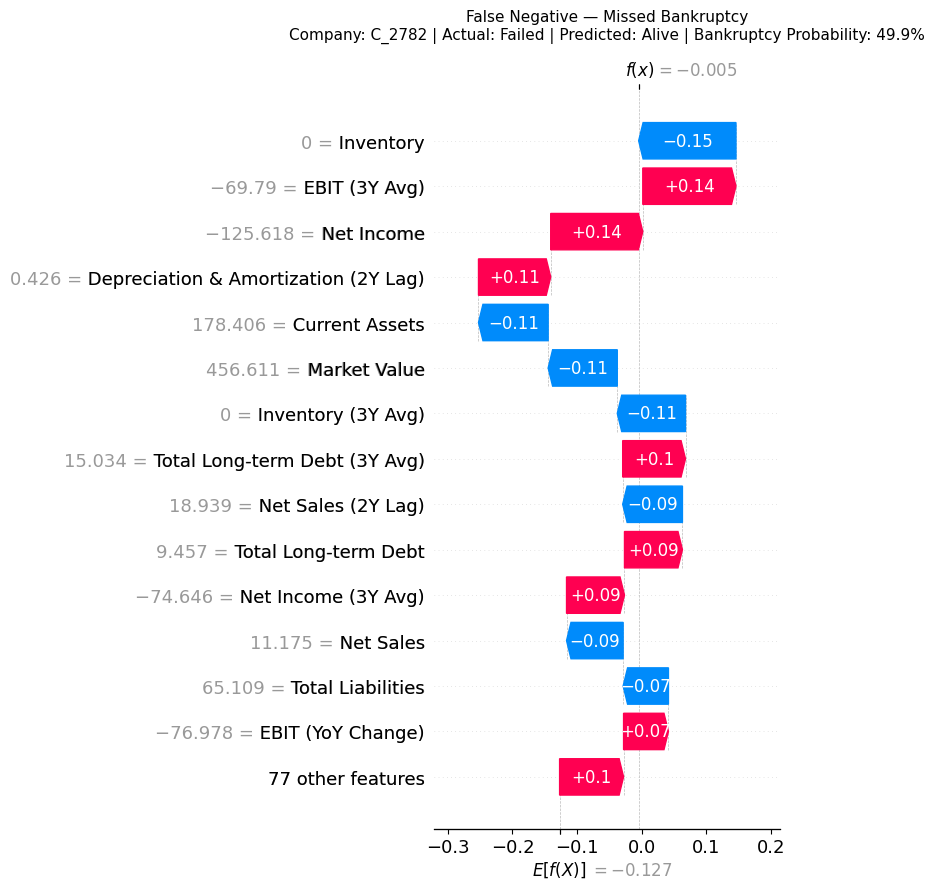

Saved: shap_false_negative_—_missed_bankruptcy.png


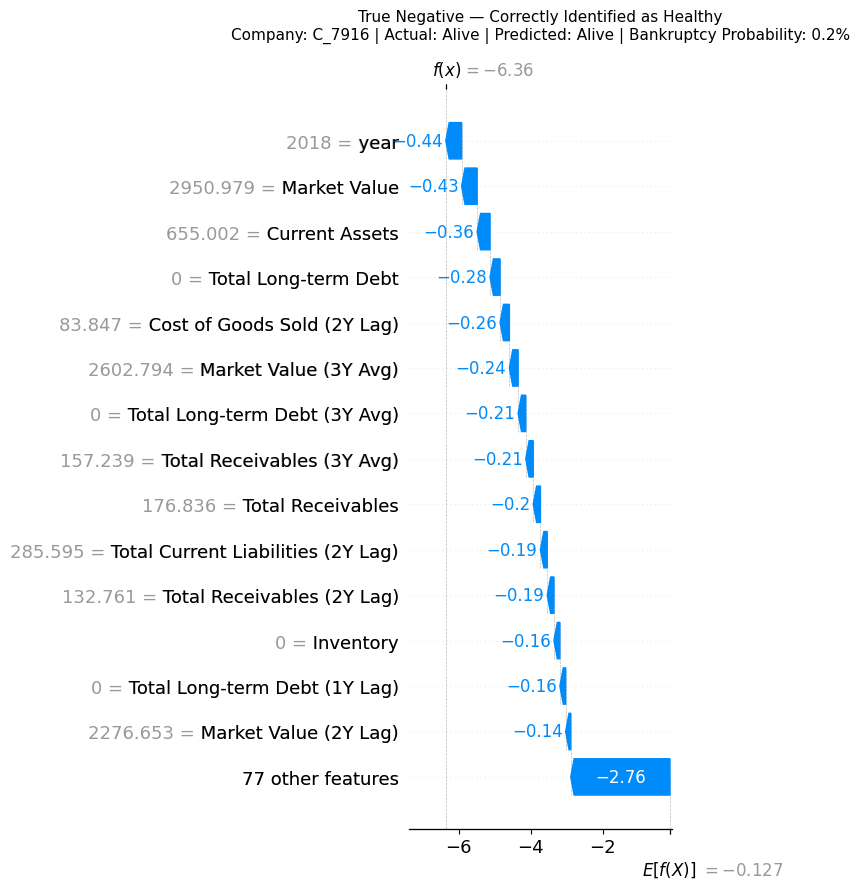

Saved: shap_true_negative_—_correctly_identified_as_healthy.png


In [55]:
# Pick specific company types to analyse
test_with_info = test.copy()
test_with_info['prob'] = test_probs
test_with_info['pred'] = test_preds

# Case 1: Company correctly predicted as failed (True Positive)
true_positives = test_with_info[
    (test_with_info['target'] == 1) &
    (test_with_info['pred'] == 1)
].sort_values('prob', ascending=False)

# Case 2: Company missed — predicted alive but actually failed (False Negative)
false_negatives = test_with_info[
    (test_with_info['target'] == 1) &
    (test_with_info['pred'] == 0)
].sort_values('prob', ascending=False)

# Case 3: Healthy company correctly identified as alive (True Negative)
true_negatives = test_with_info[
    (test_with_info['target'] == 0) &
    (test_with_info['pred'] == 0)
].sort_values('prob', ascending=True)

def plot_company_shap(row_idx, case_label, company_name, actual, predicted, prob):
    explanation = shap.Explanation(
        values      = shap_values[row_idx],
        base_values = explainer.expected_value,
        data        = X_test[FEATURES].iloc[row_idx].values,
        feature_names = FEATURE_LABELS
    )
    plt.figure(figsize=(12, 7))
    shap.plots.waterfall(explanation, max_display=15, show=False)
    plt.title(
        f'{case_label}\n'
        f'Company: {company_name} | '
        f'Actual: {"Failed" if actual==1 else "Alive"} | '
        f'Predicted: {"Failed" if predicted==1 else "Alive"} | '
        f'Bankruptcy Probability: {prob:.1%}',
        fontsize=11, pad=15
    )
    plt.tight_layout()
    fname = f'shap_{case_label.lower().replace(" ","_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

# Plot Case 1 — True Positive (highest confidence correct prediction)
if len(true_positives) > 0:
    tp = true_positives.iloc[0]
    tp_idx = test.index.get_loc(tp.name)
    plot_company_shap(
        tp_idx,
        'True Positive — Correctly Predicted Bankruptcy',
        tp['company_name'], tp['target'], tp['pred'], tp['prob']
    )

# Plot Case 2 — False Negative (missed bankruptcy)
if len(false_negatives) > 0:
    fn = false_negatives.iloc[0]
    fn_idx = test.index.get_loc(fn.name)
    plot_company_shap(
        fn_idx,
        'False Negative — Missed Bankruptcy',
        fn['company_name'], fn['target'], fn['pred'], fn['prob']
    )

# Plot Case 3 — True Negative (healthy company correctly cleared)
if len(true_negatives) > 0:
    tn = true_negatives.iloc[0]
    tn_idx = test.index.get_loc(tn.name)
    plot_company_shap(
        tn_idx,
        'True Negative — Correctly Identified as Healthy',
        tn['company_name'], tn['target'], tn['pred'], tn['prob']
    )

In [74]:
# Choose any company
company = 'C_8826'

# Get all rows for this company across the full dataset
company_all = df[df['company_name'] == company].copy()

# Predict probability for all years
company_all['bankruptcy_prob'] = final_model.predict_proba(
    company_all[FEATURES]
)[:, 1]

company_all['prediction'] = (
    company_all['bankruptcy_prob'] >= best_threshold
).astype(int)

company_all['prediction_label'] = company_all['prediction'].map(
    {0: 'Alive', 1: 'Failed'}
)

# Display clean output
result = company_all[[
    'company_name', 'year', 'status_label',
    'bankruptcy_prob', 'prediction_label'
]].copy()

result['bankruptcy_prob'] = result['bankruptcy_prob'].round(4)
result = result.sort_values('year')

print(f'Bankruptcy probability by year — {company}')
print('=' * 65)
print(result.to_string(index=False))

Bankruptcy probability by year — C_8826
company_name  year status_label  bankruptcy_prob prediction_label
      C_8826  2011       failed           0.4535           Failed
      C_8826  2012       failed           0.6843           Failed
      C_8826  2013       failed           0.8425           Failed
      C_8826  2014       failed           0.8969           Failed
      C_8826  2015       failed           0.9484           Failed
      C_8826  2016       failed           0.8702           Failed


In [72]:
companies = ['C_8826', 'C_2782', 'C_7916']
labels    = ['True Positive', 'False Negative', 'True Negative']

for company, label in zip(companies, labels):
    company_rows = df[df['company_name'] == company].copy()
    company_rows['bankruptcy_prob'] = final_model.predict_proba(
        company_rows[FEATURES]
    )[:, 1].round(4)
    company_rows['prediction_label'] = (
        company_rows['bankruptcy_prob'] >= best_threshold
    ).map({True: 'Failed', False: 'Alive'})
    
    result = company_rows[[
        'company_name', 'year', 'status_label',
        'bankruptcy_prob', 'prediction_label'
    ]].sort_values('year')
    
    print(f'=== {label} — {company} ===')
    print(result.to_string(index=False))
    print()

=== True Positive — C_8826 ===
company_name  year status_label  bankruptcy_prob prediction_label
      C_8826  2011       failed           0.4535           Failed
      C_8826  2012       failed           0.6843           Failed
      C_8826  2013       failed           0.8425           Failed
      C_8826  2014       failed           0.8969           Failed
      C_8826  2015       failed           0.9484           Failed
      C_8826  2016       failed           0.8702           Failed

=== False Negative — C_2782 ===
company_name  year status_label  bankruptcy_prob prediction_label
      C_2782  2014       failed           0.0784            Alive
      C_2782  2015       failed           0.1365            Alive
      C_2782  2016       failed           0.2901            Alive
      C_2782  2017       failed           0.4988           Failed
      C_2782  2018       failed           0.5412           Failed

=== True Negative — C_7916 ===
company_name  year status_label  bankruptcy_pr

In [73]:
import shap
import numpy as np
import pandas as pd

company = 'C_8826'

# Get all rows for this company
company_rows = df[df['company_name'] == company].copy().sort_values('year')
company_indices = company_rows.index

# Compute SHAP for all years of this company
shap_company = explainer.shap_values(company_rows[FEATURES])

# Financial labels
FEATURE_NAMES = {
    'X1': 'Current Assets', 'X2': 'Cost of Goods Sold',
    'X3': 'Depreciation & Amortization', 'X4': 'EBITDA',
    'X5': 'Inventory', 'X6': 'Net Income', 'X7': 'Total Receivables',
    'X8': 'Market Value', 'X9': 'Net Sales', 'X10': 'Total Assets',
    'X11': 'Total Long-term Debt', 'X12': 'EBIT', 'X13': 'Gross Profit',
    'X14': 'Total Current Liabilities', 'X15': 'Retained Earnings',
    'X16': 'Total Revenue', 'X17': 'Total Liabilities',
    'X18': 'Total Operating Expenses'
}

def label(col):
    for code, name in FEATURE_NAMES.items():
        if col.startswith(code) and (
            len(col) == len(code) or col[len(code)] == '_'
        ):
            suffix = col[len(code):]
            suffix_map = {
                '': '', '_lag1': ' (1Y Lag)', '_lag2': ' (2Y Lag)',
                '_yoy': ' (YoY Change)', '_roll3': ' (3Y Avg)',
            }
            return name + suffix_map.get(suffix, suffix)
    return col

FEATURE_LABELS = [label(f) for f in FEATURES]

# Build year by year SHAP decomposition table
years = company_rows['year'].values
probs = final_model.predict_proba(company_rows[FEATURES])[:, 1]

# For each year get top 10 features by absolute SHAP
print(f'Year-on-Year SHAP Decomposition — {company}')
print('=' * 75)

for i, year in enumerate(years):
    sv = shap_company[i]
    prob = probs[i]
    
    # Get top 10 by absolute SHAP value
    top_idx = np.argsort(np.abs(sv))[::-1][:10]
    
    print(f'\nYear: {year} | Bankruptcy Probability: {prob:.1%} | '
          f'Prediction: {"FAILED" if prob >= best_threshold else "ALIVE"}')
    print(f'Baseline: {explainer.expected_value:.3f} → '
          f'Model output: {np.sum(sv) + explainer.expected_value:.3f}')
    print('-' * 75)
    print(f'{"Feature":<40} {"Feature Value":>15} {"SHAP":>10} {"Direction":>12}')
    print('-' * 75)
    
    for idx in top_idx:
        feat_label = FEATURE_LABELS[idx]
        feat_val   = company_rows[FEATURES].iloc[i, idx]
        shap_val   = sv[idx]
        direction  = '↑ RISK' if shap_val > 0 else '↓ RISK'
        print(f'{feat_label:<40} {feat_val:>15.2f} {shap_val:>10.4f} {direction:>12}')
    
    remaining_shap = np.sum(sv) - np.sum(sv[top_idx])
    print(f'{"Remaining features (combined)":<40} {"":>15} '
          f'{remaining_shap:>10.4f}')
    print()

# Summary table — how key metrics evolved year on year
print()
print('=' * 75)
print('KEY FINANCIAL METRICS — YEAR ON YEAR')
print('=' * 75)

key_features = ['X8', 'X12', 'X6', 'X11', 'X17', 'X4']
key_labels   = ['Market Value', 'EBIT', 'Net Income',
                'Total Long-term Debt', 'Total Liabilities', 'EBITDA']

header = f'{"Metric":<30}' + ''.join([f'{y:>10}' for y in years])
print(header)
print('-' * 75)

for feat, lbl in zip(key_features, key_labels):
    row = f'{lbl:<30}'
    for val in company_rows[feat].values:
        row += f'{val:>10.0f}'
    print(row)

print()
print('Bankruptcy Probability      ', end='')
for p in probs:
    print(f'{p:>9.1%}', end='')
print()

Year-on-Year SHAP Decomposition — C_8826

Year: 2011 | Bankruptcy Probability: 45.4% | Prediction: FAILED
Baseline: -0.127 → Model output: -0.186
---------------------------------------------------------------------------
Feature                                    Feature Value       SHAP    Direction
---------------------------------------------------------------------------
Total Operating Expenses (2Y Lag)                  46.07     0.3071       ↑ RISK
year                                             2011.00    -0.2605       ↓ RISK
Total Current Liabilities (2Y Lag)                 38.53     0.1641       ↑ RISK
Net Income (3Y Avg)                                12.69    -0.1604       ↓ RISK
Retained Earnings (1Y Lag)                         12.53    -0.1320       ↓ RISK
Depreciation & Amortization                        31.51     0.1317       ↑ RISK
Inventory (3Y Avg)                                  3.32     0.1206       ↑ RISK
Retained Earnings (2Y Lag)                         12.